# Exploratory Data Analysis

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

# Scalers
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer, MaxAbsScaler

# Dimensionality Reduction - sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE

# Dimensionality Reduction - umap-learn
import umap.umap_ as umap
# For reproducibility
import random

In [2]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [3]:
metadata.head()

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America


In [4]:
len(metadata[metadata['Lifestyle'] == 'Rural'])

123

In [5]:
len(metadata) - len(metadata[metadata['Lifestyle'] == 'Rural'])

85

In [6]:
len(metadata)

208

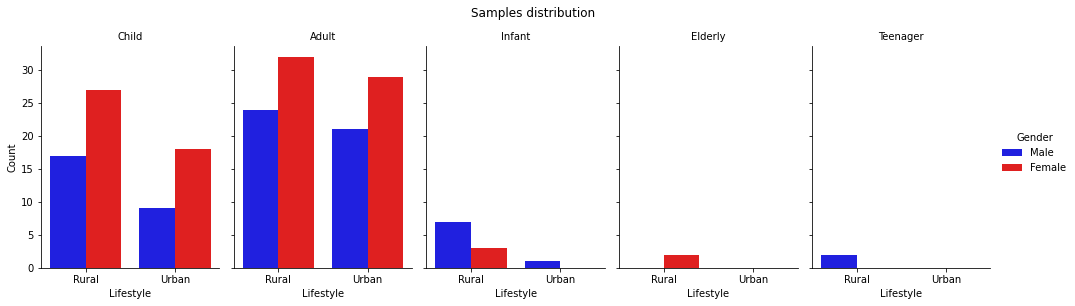

In [7]:
custom_palette = {'Male': 'blue', 'Female': 'red'}  
g = sns.catplot(x='Lifestyle', hue='Gender', col='Age group', 
                data=metadata, kind='count', height=4, aspect=0.7, palette=custom_palette)
g.set_axis_labels('Lifestyle', 'Count')
g.set_titles('{col_name}')
g.fig.suptitle('Samples distribution', y=1.05)
# plt.savefig('../imgs/samples_distribution.png', dpi = 500)
plt.show()


Los puntos que quedan solos pueden ser de los grupos menos representados CHECAR

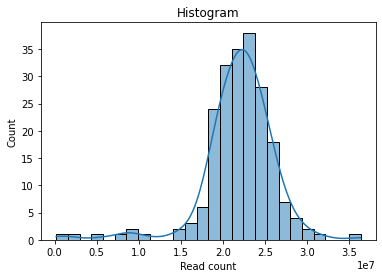

In [8]:
sns.histplot(metadata['Read count'], kde=True)
plt.xlabel('Read count')
plt.ylabel('Count')
plt.title('Histogram')
# plt.savefig('../imgs/reads_histogram.png', dpi = 500)
plt.show()

In [9]:
metadata.sort_values('Read count').head(2)

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
24,37082_3_16,37082_3#16,GI1_LA9438085,B21,B9/17,185470,37082_3_16,Latinbiota,Healthy,NaN,22.5,NaN,31.0,Adult,Female,Rural,Mexico,North America
37,37082_2_4,37082_2#4,GI1_LA9438025,C42,C41,1779530,37082_2_4,Latinbiota,Healthy,NaN,17.8,NaN,8.0,Child,Male,Urban,Mexico,North America


In [10]:
Q1 = metadata['Read count'].quantile(0.25)
Q3 = metadata['Read count'].quantile(0.75)

In [11]:
IQR = Q3 - Q1

# Step 3: Define the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [12]:
outliers = metadata[(metadata['Read count'] < lower_bound) | (metadata['Read count'] > upper_bound)]

In [13]:
outliers

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
5,37082_3_4,37082_3#4,GI1_LA9438070,159,130,31944470,37082_3_4,Latinbiota,Healthy,NaN,22.4,NaN,35.0,Adult,Female,Rural,Mexico,North America
24,37082_3_16,37082_3#16,GI1_LA9438085,B21,B9/17,185470,37082_3_16,Latinbiota,Healthy,NaN,22.5,NaN,31.0,Adult,Female,Rural,Mexico,North America
29,37082_3_11,37082_3#11,GI1_LA9438079,62,51,5669548,37082_3_11,Latinbiota,Healthy,NaN,28.0,NaN,34.0,Adult,Female,Rural,Mexico,North America
33,37082_2_8,37082_2#8,GI1_LA9438033,C50,C49,36372476,37082_2_8,Latinbiota,Healthy,NaN,NaN,NaN,33.0,Adult,Male,Urban,Mexico,North America
36,37082_2_5,37082_2#5,GI1_LA9438026,C43,C42,8556292,37082_2_5,Latinbiota,Healthy,NaN,NaN,NaN,NaN,NaN,Female,Urban,Mexico,North America
37,37082_2_4,37082_2#4,GI1_LA9438025,C42,C41,1779530,37082_2_4,Latinbiota,Healthy,NaN,17.8,NaN,8.0,Child,Male,Urban,Mexico,North America
97,37035_7_23,37035_7#23,GI1_LA9825342,114,114,8502694,37035_7_23,Latinbiota,Healthy,NaN,NaN,NaN,NaN,NaN,NaN,Rural,Mexico,North America
150,37035_1_4,37035_1#4,GI1_LA9438113,125,135,11001358,37035_1_4,Latinbiota,Healthy,NaN,14.9,NaN,9.0,Child,Female,Rural,Mexico,North America
179,36703_3_6,36703_3#6,GI1_LA9438031,C48,C47,8934960,36703_3_6,Latinbiota,Healthy,NaN,NaN,NaN,4.0,Child,Male,Urban,Mexico,North America


In [14]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']


In [15]:
metadata[metadata['Lane'].isin(rare)][['Lane', 'Read count', 'Health state', 'BMI', 'Age', 'Age group', 'Gender', 'Lifestyle']]

,Lane,Read count,Health state,BMI,Age,Age group,Gender,Lifestyle
24,37082_3#16,185470,Healthy,22.5,31.0,Adult,Female,Rural
37,37082_2#4,1779530,Healthy,17.8,8.0,Child,Male,Urban
103,37035_7#18,22573852,Healthy,NaN,NaN,NaN,NaN,Rural
130,37035_2#22,24769900,Healthy,NaN,8.0,Child,Male,Urban
181,36703_3#4,20667418,Healthy,NaN,NaN,NaN,NaN,Urban
195,36703_3#20,16695310,Healthy,14.6,7.0,Child,Female,Rural


In [3]:
# Scalers dictionary
scalers = {
    "minmax": MinMaxScaler(),
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "normalize": Normalizer(),
    "maxabs": MaxAbsScaler()
}

# Reducers dictionary
reducers = {
    "pca": PCA(n_components=2),
    "isomap": Isomap(n_components=2),
    "tsne": TSNE(n_components=2, random_state=42),
    "umap": umap.UMAP(n_components=2, random_state=42)
}


In [17]:
def reduce_and_plot(X, scaler_name="standard", reducer_name="pca", labels=None, figsize=(8, 6), title=None):
    """
    Apply scaler and dimensionality reduction, then plot.

    Parameters:
        X (array-like): Input data (n_samples, n_features)
        scaler_name (str): One of "minmax", "standard", "robust", "normalize", "maxabs"
        reducer_name (str): One of "pca", "isomap", "tsne", "umap"
        labels (array-like): Optional labels for coloring points
        figsize (tuple): Size of the plot
        title (str): Optional title for the plot
    """
    # Scale the data
    if scaler_name not in scalers:
        raise ValueError(f"Unknown scaler: {scaler_name}")
    X_scaled = scalers[scaler_name].fit_transform(X)

    # Reduce the data
    if reducer_name not in reducers:
        raise ValueError(f"Unknown reducer: {reducer_name}")
    X_reduced = reducers[reducer_name].fit_transform(X_scaled)

    # Plot
    plt.figure(figsize=figsize)
    if labels is not None:
        scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap="Set1", s=40, alpha=0.8)
        plt.legend(*scatter.legend_elements(), title="Labels")
    else:
        plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=40, alpha=0.8)
    
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title or f"{reducer_name.upper()} with {scaler_name.capitalize()} Scaler")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def read_data():
    metadata = pd.read_excel('../datasets/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')
    taxonomy = pd.read_csv('../datasets/bracken_taxonomy.csv', index_col = 0)
    taxonomy = taxonomy.T
    pathways_unstratified = pd.read_csv('../datasets/latinbiota_pathabundance_unstratified.tsv', sep = '\t', index_col = 0)
    pathways_unstratified = pathways_unstratified[[x for x in pathways_unstratified.columns if '.1' not in x]]
    pathways_unstratified.drop('UNMAPPED', axis = 0, inplace = True)
    pathways_unstratified.drop('UNINTEGRATED', axis = 0, inplace = True)
    pathways_unstratified = pathways_unstratified.T
    pathways_unstratified.index = [x.replace('_paired_Abundance', '') for x in pathways_unstratified.index]
    
    return metadata, taxonomy, pathways_unstratified

In [7]:
metadata, taxonomy, pathways = read_data()

In [8]:
sample_outliers = ['37082_3#16','37082_2#4','37035_2#22','37035_7#18','36703_3#20','36703_3#4']

taxonomy.drop(sample_outliers, axis = 0, inplace = True)
pathways.drop(sample_outliers, axis = 0, inplace = True)

In [9]:
lifestyle = []
for sample in taxonomy.index:
    lifestyle.append(metadata[metadata['Lane'] == sample]['Lifestyle'].iloc[0])

In [10]:
taxonomy

,2763670,46228,33039,33038,166486,301301,2763062,39485,418240,2479767,...,1923324,2845935,1475063,35783,103690,2734056,2419609,2704034,3048295,2845556
37035_2#16,597259.0,343254.0,39335.0,35129.0,225002.0,128437.0,25426.0,240332.0,53240.0,27147.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37082_3#26,4681.0,10905.0,81632.0,13430.0,20487.0,6363.0,4395.0,5792.0,522347.0,85723.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_7#13,749.0,1451.0,21871.0,1591.0,5019.0,3105.0,882.0,11461.0,12640.0,10090.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_1#27,3872.0,4599.0,86240.0,5501.0,17020.0,5048.0,2108.0,11433.0,295076.0,14710.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37082_1#17,90006.0,6411.0,113806.0,11018.0,60139.0,34079.0,8053.0,8525.0,25112.0,8832.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#13,8230.0,5638.0,39957.0,6629.0,56233.0,78750.0,7984.0,91982.0,20573.0,4719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_7#9,4953.0,4881.0,143488.0,5812.0,19461.0,6050.0,2554.0,68766.0,67981.0,13436.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37082_1#13,24629.0,10078.0,91015.0,15878.0,119840.0,40227.0,14961.0,67722.0,42818.0,8642.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_7#3,5205.0,9862.0,99575.0,8973.0,54036.0,21343.0,9214.0,380716.0,25627.0,8516.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


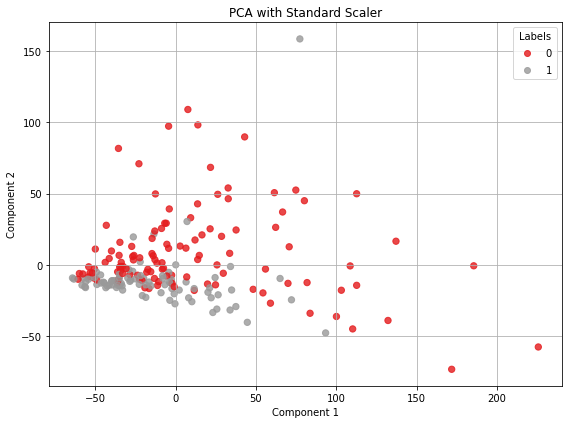

In [18]:
reduce_and_plot(taxonomy, scaler_name="standard", reducer_name="pca", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

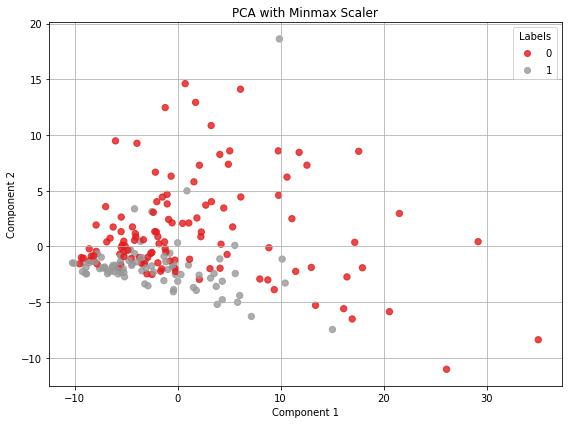

In [19]:
reduce_and_plot(taxonomy, scaler_name="minmax", reducer_name="pca", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

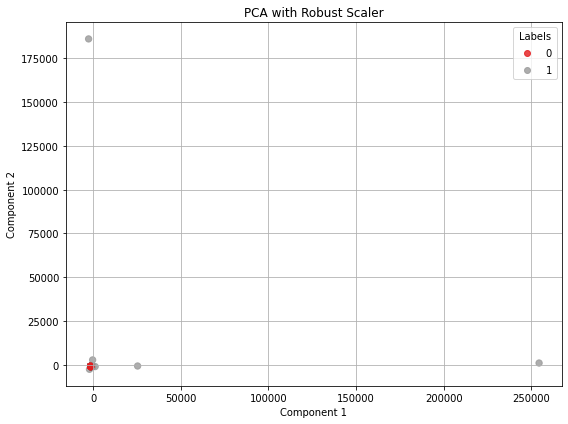

In [20]:
reduce_and_plot(taxonomy, scaler_name="robust", reducer_name="pca", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

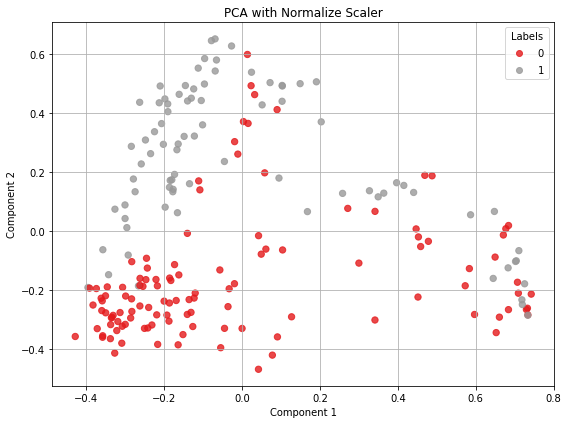

In [21]:
reduce_and_plot(taxonomy, scaler_name="normalize", reducer_name="pca", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

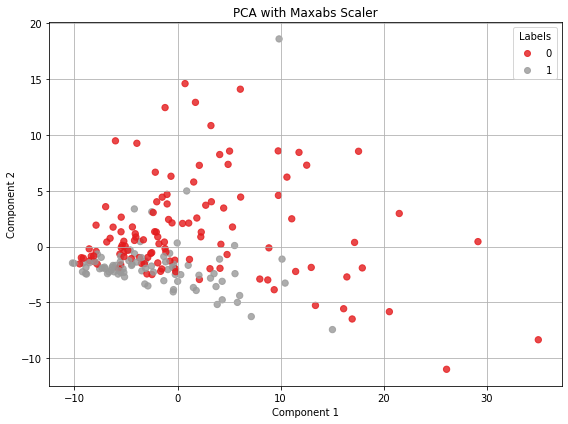

In [22]:
reduce_and_plot(taxonomy, scaler_name="maxabs", reducer_name="pca", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

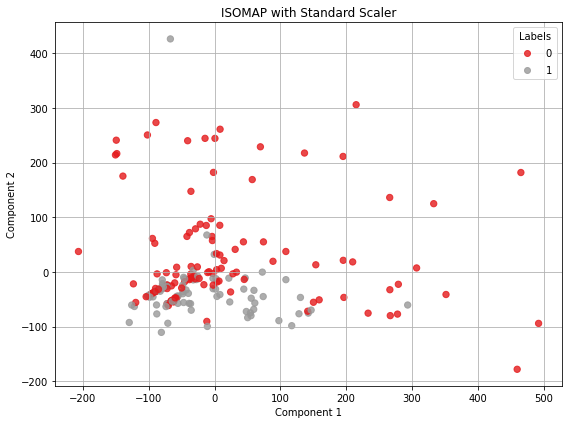

In [24]:
reduce_and_plot(taxonomy, scaler_name="standard", reducer_name="isomap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

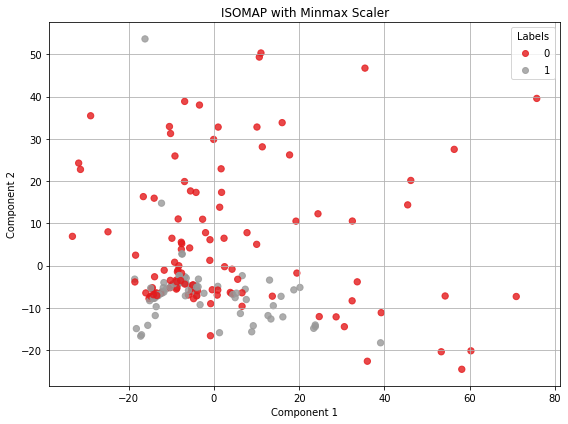

In [25]:
reduce_and_plot(taxonomy, scaler_name="minmax", reducer_name="isomap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

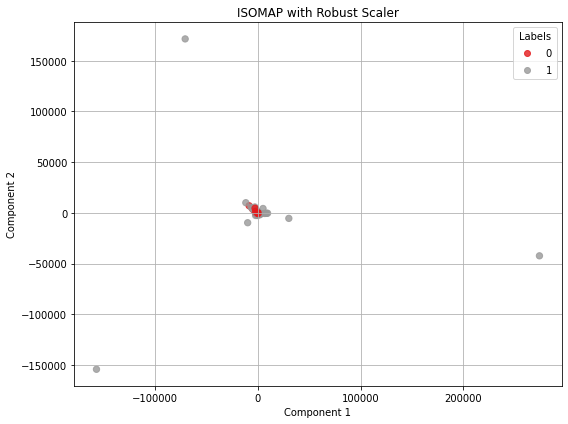

In [26]:
reduce_and_plot(taxonomy, scaler_name="robust", reducer_name="isomap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

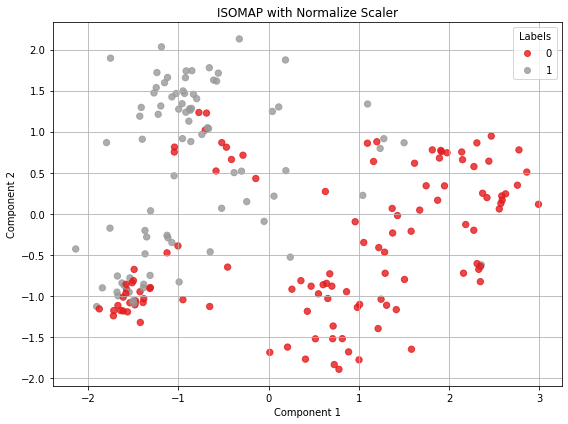

In [27]:
reduce_and_plot(taxonomy, scaler_name="normalize", reducer_name="isomap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

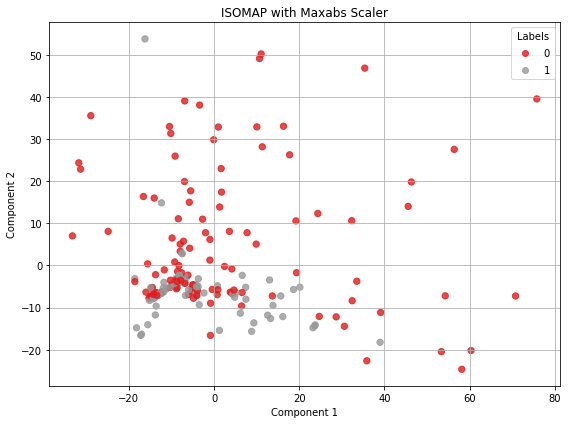

In [28]:
reduce_and_plot(taxonomy, scaler_name="maxabs", reducer_name="isomap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

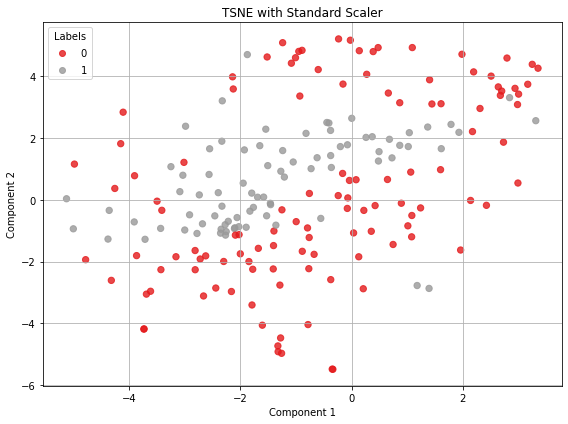

In [29]:
reduce_and_plot(taxonomy, scaler_name="standard", reducer_name="tsne", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

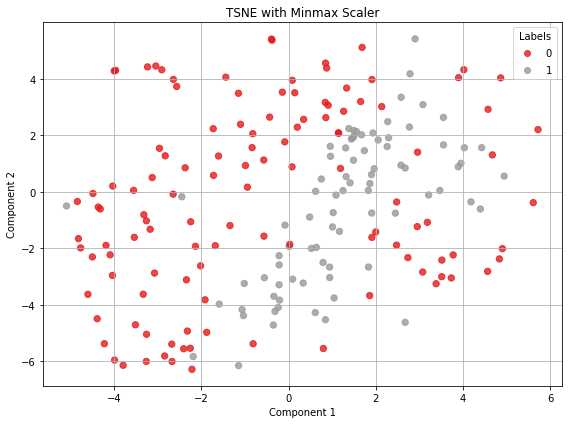

In [30]:
reduce_and_plot(taxonomy, scaler_name="minmax", reducer_name="tsne", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

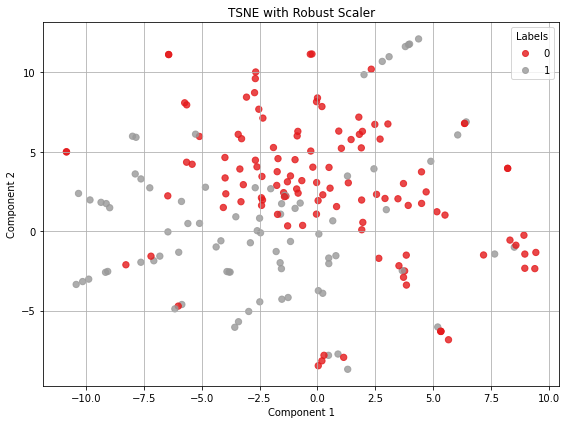

In [31]:
reduce_and_plot(taxonomy, scaler_name="robust", reducer_name="tsne", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

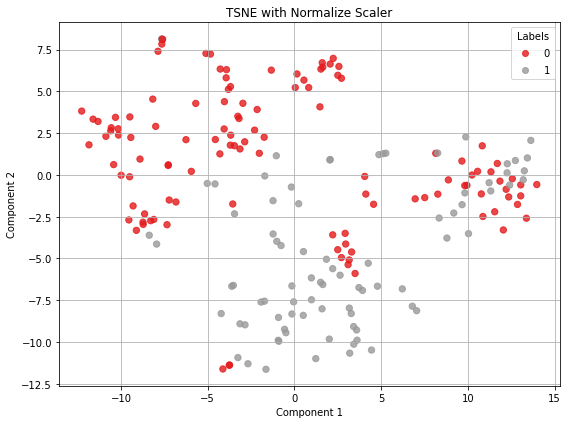

In [32]:
reduce_and_plot(taxonomy, scaler_name="normalize", reducer_name="tsne", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

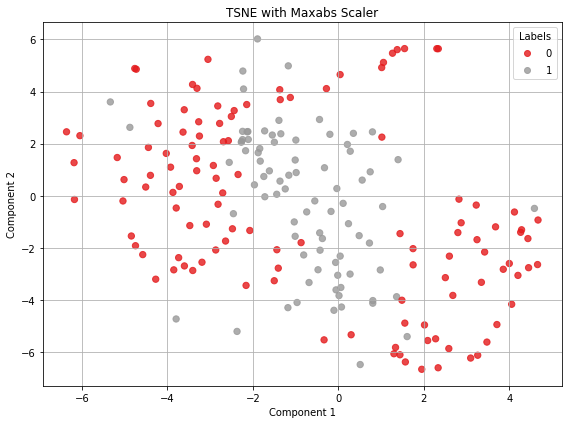

In [33]:
reduce_and_plot(taxonomy, scaler_name="maxabs", reducer_name="tsne", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

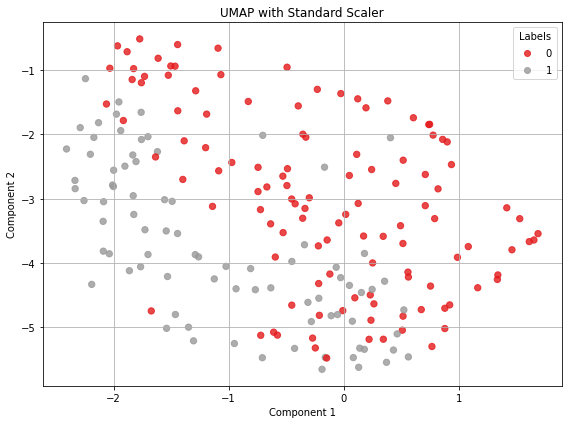

In [34]:
reduce_and_plot(taxonomy, scaler_name="standard", reducer_name="umap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

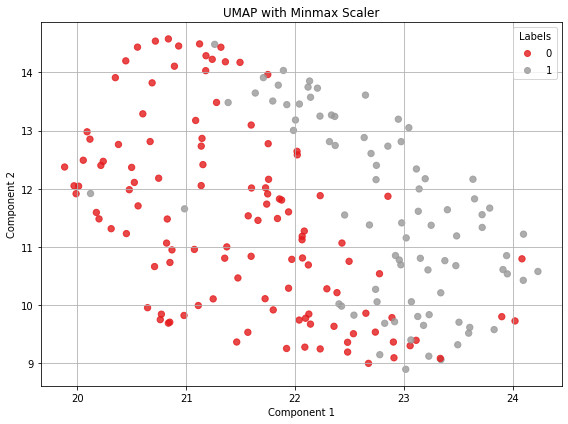

In [35]:
reduce_and_plot(taxonomy, scaler_name="minmax", reducer_name="umap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

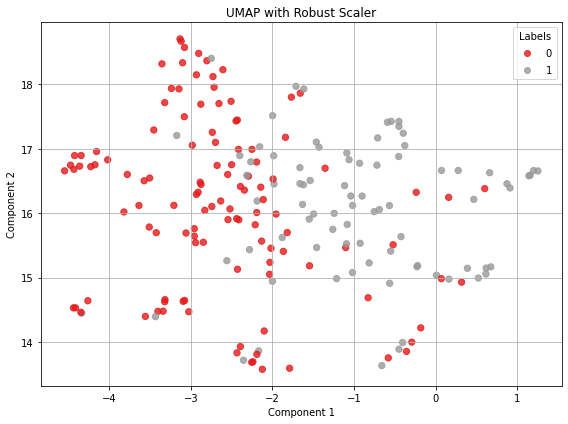

In [36]:
reduce_and_plot(taxonomy, scaler_name="robust", reducer_name="umap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

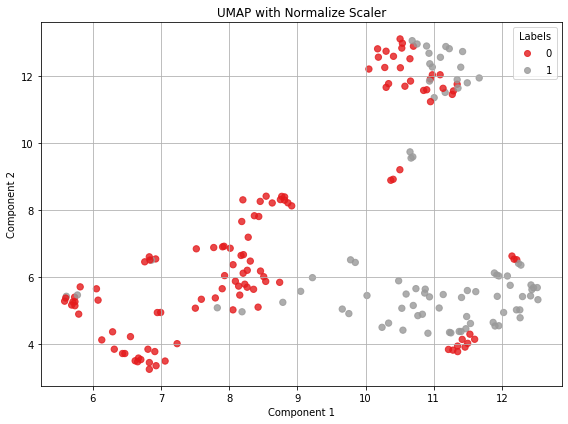

In [39]:
reduce_and_plot(taxonomy, scaler_name="normalize", reducer_name="umap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

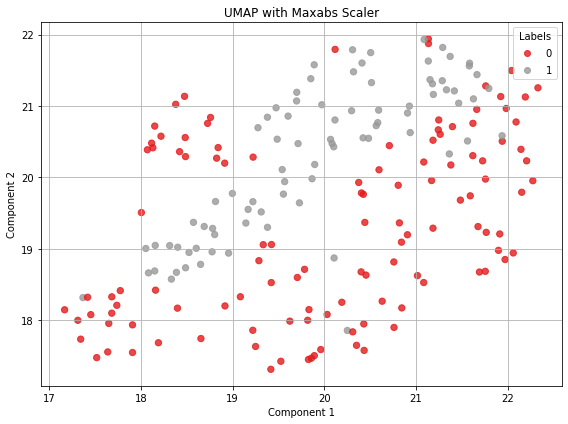

In [38]:
reduce_and_plot(taxonomy, scaler_name="maxabs", reducer_name="umap", labels=[0 if x == 'Rural' else 1 for x in lifestyle])

In [42]:
import kmapper as km
from sklearn.cluster import DBSCAN

In [43]:
X_scaled_pca = Normalizer().fit_transform(taxonomy)
pca = PCA(n_components=0.9, svd_solver='full')
X_pca = pca.fit_transform(X_scaled_pca)

mapper2 = km.KeplerMapper(verbose=1)
lens2 = X_pca  # Or PCA[:,0:2] if you want a 2D lens
graph2 = mapper2.map(lens2, X_pca,
                     cover=km.Cover(n_cubes=10, perc_overlap=0.1),
                     clusterer=DBSCAN(eps=1, min_samples=3))

mapper2.visualize(graph2, path_html="mapper_pca90.html", title="Mapper: PCA 90% + L2", custom_tooltips=np.array(labels))

KeplerMapper(verbose=1)
Mapping on data shaped (199, 34) using lens shaped (199, 34)



MemoryError: 

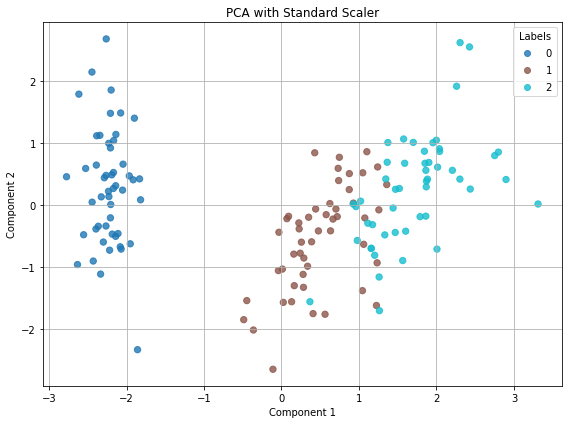

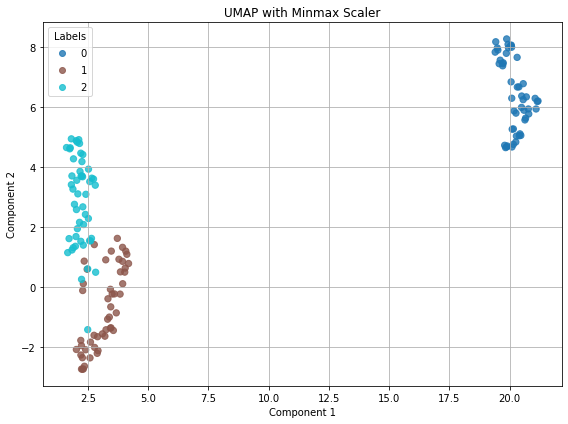

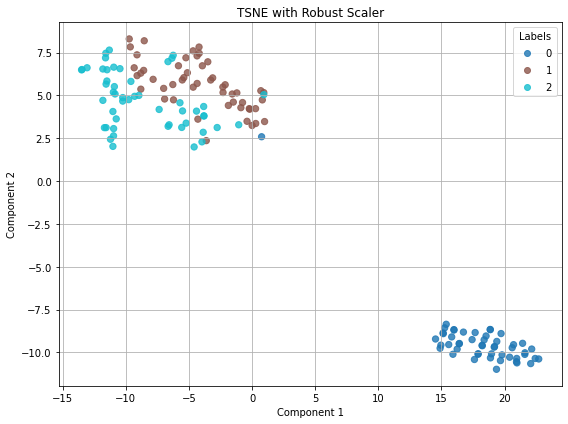

In [5]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

reduce_and_plot(X, scaler_name="standard", reducer_name="pca", labels=y)
reduce_and_plot(X, scaler_name="minmax", reducer_name="umap", labels=y)
reduce_and_plot(X, scaler_name="robust", reducer_name="tsne", labels=y)

In [12]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])